In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


In [50]:
data = pd.read_csv('Rainfall.csv')

In [52]:
display(data.describe())

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [53]:
print(data.shape)

(2190, 13)


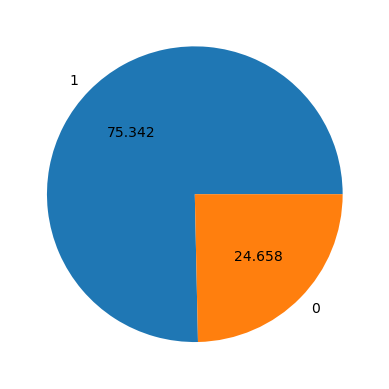

In [54]:
plt.pie(x = data.rainfall.value_counts().values, labels = data.rainfall.unique(), autopct = '%1.3f')
plt.show()

<Axes: >

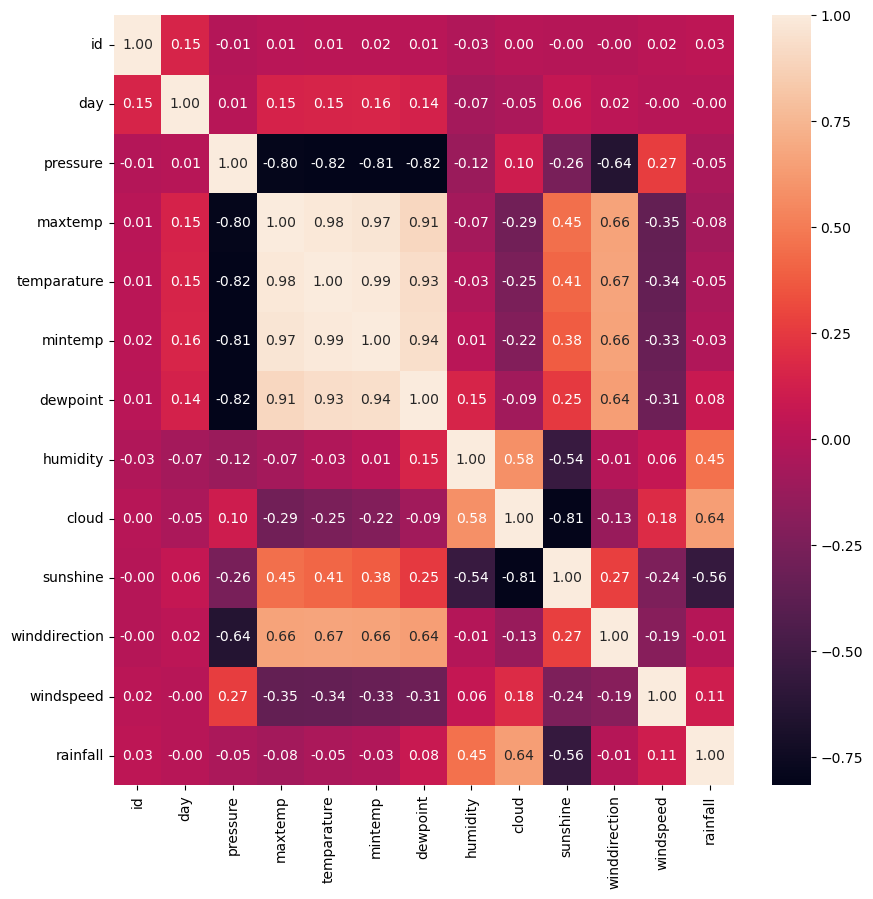

In [81]:
plt.figure(figsize = (10, 10))
sns.heatmap(data.corr(), annot = True, fmt = '.2f')

In [55]:
# In case we need validation dataset for hyperparamater optimization
input_columns = ['humidity', 'cloud', 'pressure', 'windspeed', 'mintemp']

input_data = data[input_columns]
output_data = data['rainfall']
input_train, input_test, output_train, output_test = train_test_split(input_data, output_data, 
                                                                      test_size = 0.2, shuffle = False, random_state = 42)


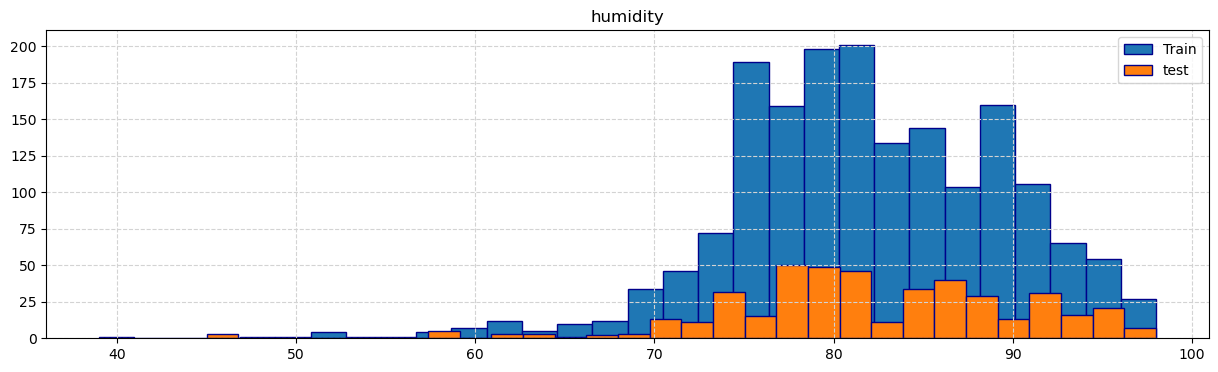

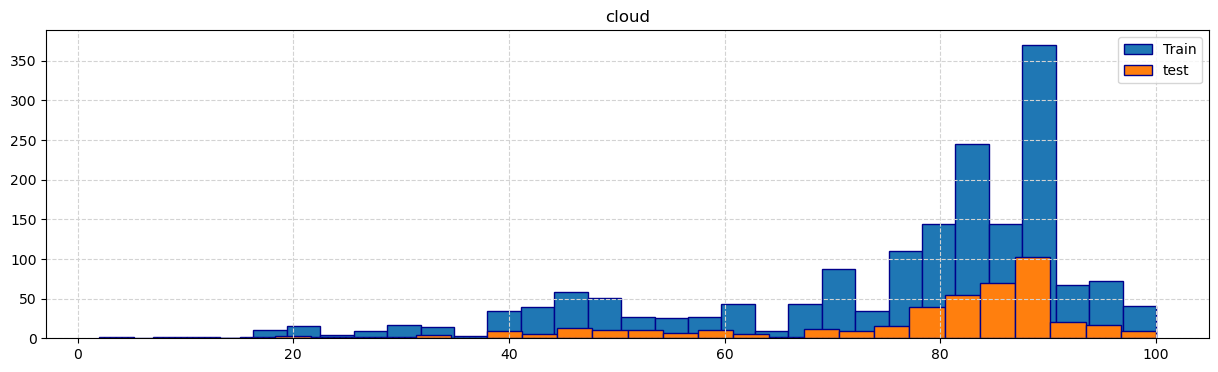

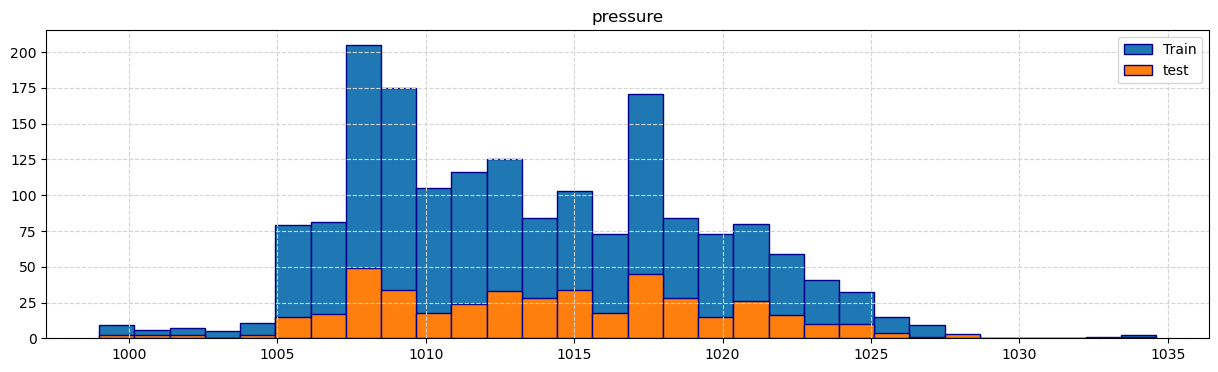

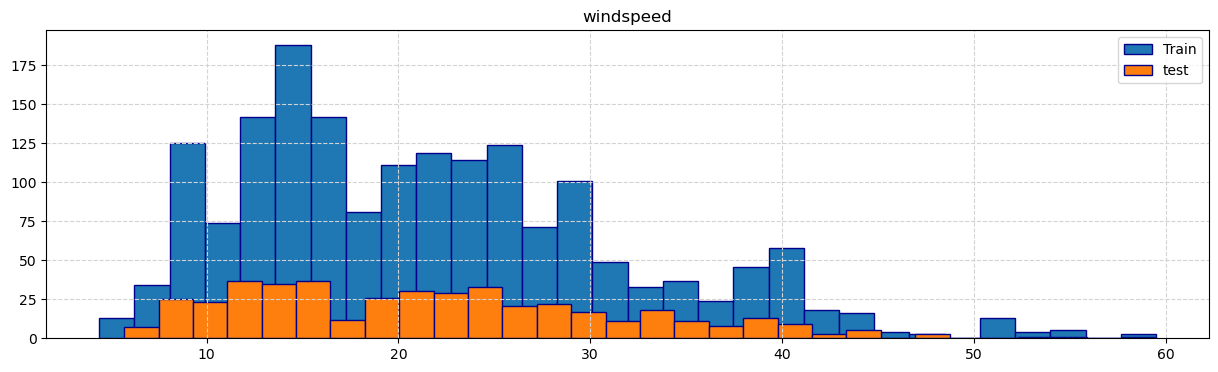

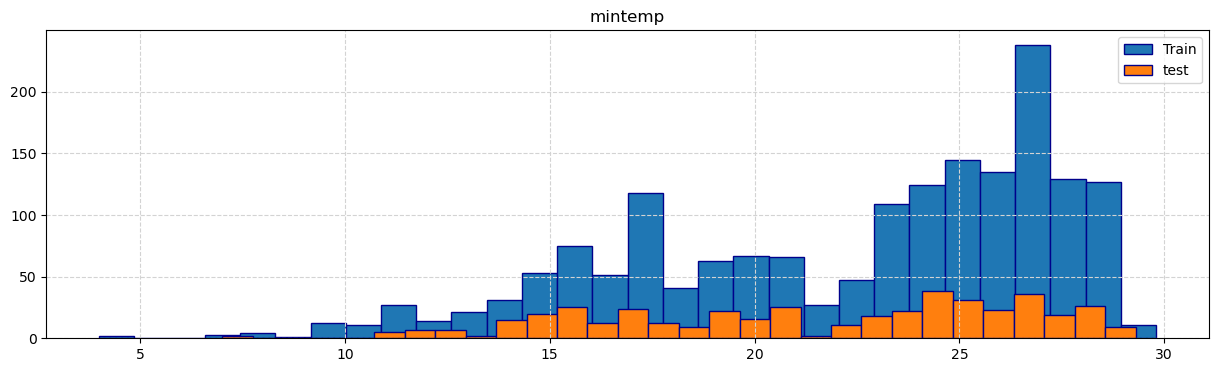

In [56]:
for column in input_train.columns:
    
    plt.figure(figsize=(15, 4))
    plt.hist(input_train[column], bins = 30, edgecolor = 'darkblue', label = 'Train')
    plt.hist(input_test[column], bins = 30, edgecolor = 'darkblue', label = 'test')
    plt.title(column)
    plt.legend()
    plt.grid(True, linestyle = '--', color = 'lightgrey')
    plt.show()


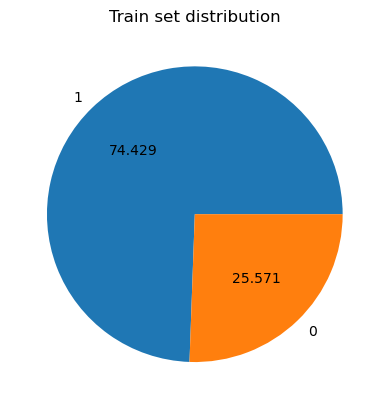

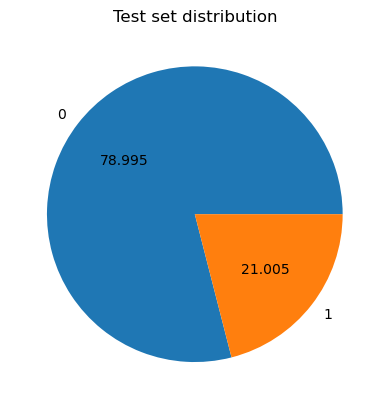

In [57]:
plt.pie(x = output_train.value_counts().values, labels = output_train.unique(), autopct = '%1.3f')
plt.title('Train set distribution')
plt.show()

plt.pie(x = output_test.value_counts().values, labels = output_test.unique(), autopct = '%1.3f')
plt.title('Test set distribution')
plt.show()


In [58]:
print('n_samples   = {}'.format(len(output_train)))
print('n_0 samples = {}'.format(output_train.value_counts()[0]))
print('n_1 samples = {}'.format(output_train.value_counts()[1]))

n_samples   = 1752
n_0 samples = 448
n_1 samples = 1304


In [59]:
# Normalize input data for better convergance and faster

scaler = StandardScaler()
in_train = pd.DataFrame(scaler.fit_transform(input_train), columns = input_train.columns)
in_test = pd.DataFrame(scaler.fit_transform(input_test), columns = input_train.columns)


In [60]:
#in_train = pd.DataFrame(train_input_scal, columns = input_train.columns)
#in_test = pd.DataFrame(test_input_scal, columns = input_train.columns)


In [61]:
# V4 making the temperature into 3 distinct values: low, medium, and high. But didn't really contribute to better score
#in_train['mintemp'] = pd.cut(input_train['mintemp'], bins=[-np.inf, 5, 15, np.inf], labels=[0, 1, 2]).astype(int)
#in_val['mintemp'] = pd.cut(input_val['mintemp'], bins=[-np.inf, 5, 15, np.inf], labels=[0, 1, 2]).astype(int).reset_index(drop = True)
#in_sub['mintemp'] = pd.cut(input_submit['mintemp'], bins=[-np.inf, 5, 15, np.inf], labels=[0, 1, 2]).astype(int)

In [62]:
def map_value(value):
    if 79<= value < 172:
        # Spring
        return 1
    elif 172 <= value < 266:
        # Summer
        return 2
    elif 266 <= value <355:
        # Automn
        return 3
    else:
        # Winter
        return 4

In [63]:
# V5 adding the season (didn't contribute in improving the model) 
# V6 adding the month to the input data

#in_train['month'] = data_train.day.apply(map_value)
#in_test['month'] = data_test.day.reset_index(drop = True).apply(map_value)
#input_columns.append('month')

In [64]:
def display_result(result):
    print('ROC AUC score: {:0.3f}'.format(result['roc_test']))
    print('Coef:         ',result['coef'])
    print('Intercept:    ', result['intercept'])
    print('NB iteration: ', result['nb_iteration'])

    #print(f'Accuracy: {accuracy:.4f}')
    #print(f'F1-score: {f1:.4f}')
    #print(f'Recall: {recall:.4f}')
    #print(f'Precision: {precision:.4f}')

In [65]:
def model_run(paramaters = None, display = True):

    if paramaters is None:
        model = LogisticRegression(random_state = 20)
    else:
        model = LogisticRegression(random_state = 20, **paramaters)
    model.fit(in_train, output_train)
    y_pred = model.predict(in_test)

    roc_test = roc_auc_score(output_test, y_pred)

    #accuracy = accuracy_score(output_val, y_pred)
    #f1 = f1_score(output_val, y_pred, average='weighted')
    #recall = recall_score(output_val, y_pred, average='weighted')
    #precision = precision_score(output_val, y_pred, average='weighted')    

    coef=['{:} : {:} '.format(input_columns[i], round(model.coef_[0][i], 2)) for i in np.arange(0, len(input_columns))]
    intercept= round(model.intercept_[0], 3)
    nb_iteration = model.n_iter_[0]

    results = {'model': model, 'roc_test':roc_test ,'coef':coef, 'intercept':intercept, 'nb_iteration': nb_iteration}

    if display == True:
        display_result(results)
    return results

In [66]:
results = model_run()

ROC AUC score: 0.760
Coef:          ['humidity : 0.53 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.11 ', 'mintemp : 0.14 ']
Intercept:     1.524
NB iteration:  8


##### We analyse below the impact of the solver only on the predictions

Conclusion: after the run we found all the ROC score identical. But the difference is spotted at the number of iterations of the optimization algorithm to reach convergence.

In [67]:
# impact of solver
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']

for solver in solvers:
    print('Solver:        {:}'.format(solver))
    results = model_run({'solver': solver})
    print()
    print('----------------------------------------------------------------------------------------------------------------')
    print()


Solver:        lbfgs
ROC AUC score: 0.760
Coef:          ['humidity : 0.53 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.11 ', 'mintemp : 0.14 ']
Intercept:     1.524
NB iteration:  8

----------------------------------------------------------------------------------------------------------------

Solver:        liblinear
ROC AUC score: 0.760
Coef:          ['humidity : 0.52 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.11 ', 'mintemp : 0.14 ']
Intercept:     1.513
NB iteration:  5

----------------------------------------------------------------------------------------------------------------

Solver:        newton-cg
ROC AUC score: 0.760
Coef:          ['humidity : 0.53 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.11 ', 'mintemp : 0.14 ']
Intercept:     1.523
NB iteration:  5

----------------------------------------------------------------------------------------------------------------

Solver:        newton-cholesky
ROC AUC score: 0.760
Coef:        

##### We analyse below the impact of penalty. Since the penalty depend on the solver used, and since we found above that the solvers are not impacting the predictions, we will set for each penalty a random solver. For penalty elasticnet the l1_ratio parameter is mandatory, so we will set different l1_ratio to different values to analyse its impact on the predictions.

Conclusion: The solvers are not impacting the predictions. Only the number of iterations may be different. The l1_ratio when working with elasticnet did not have any impact as well on the predictions

In [68]:
penalties = ['l1', 'l2', 'elasticnet']
ratio = None
for penalty in penalties:
    print('penalty:      ',penalty)
    if penalty == 'l1':
        # l1 works with the solvers: liblinear or saga. 
        # We choosed liblinear below
        solver = 'liblinear'
        results = model_run({'penalty' : penalty, 'solver': solver, 'l1_ratio' : ratio})
    elif penalty =='l2':
        # l2 works with the solvers: lbfgs, liblinear, newton-cg, newton-cholesky, sag, saga.
        # We choosed lbfgs below
        solver = 'lbfgs'
        results = model_run({'penalty' : penalty, 'solver': solver, 'l1_ratio' : ratio})
    else:
        # elasticnet works with the solver saga only. 
        # We tried different l_1 ratio which is a hyperaparameter used only for saga solver
        solver = 'saga'
        ratio = 0.5
        for r in np.arange(0, 1, 0.3):
            print('l1_ratio:     ', r)
            results = model_run({'penalty' : penalty, 'solver': solver, 'l1_ratio' : r})
            print('*************************************************************************************************')
    
    print()
    print('-------------------------------------------------------------------------------------------------------------')
    print()


penalty:       l1
ROC AUC score: 0.760
Coef:          ['humidity : 0.52 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.1 ', 'mintemp : 0.13 ']
Intercept:     1.515
NB iteration:  13

-------------------------------------------------------------------------------------------------------------

penalty:       l2
ROC AUC score: 0.760
Coef:          ['humidity : 0.53 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.11 ', 'mintemp : 0.14 ']
Intercept:     1.524
NB iteration:  8

-------------------------------------------------------------------------------------------------------------

penalty:       elasticnet
l1_ratio:      0.0
ROC AUC score: 0.760
Coef:          ['humidity : 0.53 ', 'cloud : 1.54 ', 'pressure : -0.28 ', 'windspeed : 0.11 ', 'mintemp : 0.14 ']
Intercept:     1.523
NB iteration:  15
*************************************************************************************************
l1_ratio:      0.3
ROC AUC score: 0.760
Coef:          ['humidity : 0.53 ', '

##### We analyse below the impact of class weight.

Conclusion: We see a noticeable enhancement in the predictions when we set the class_weight parameter to balanced. We see also impact on the Coefficient of the features

In [69]:
results = model_run({'class_weight': 'balanced'})

ROC AUC score: 0.811
Coef:          ['humidity : 0.56 ', 'cloud : 1.59 ', 'pressure : -0.34 ', 'windspeed : 0.13 ', 'mintemp : 0.11 ']
Intercept:     0.477
NB iteration:  9


##### We analyse below the impact of intercept scaling. Solver must be set to 'liblinear' and 'fit_intercept' must be set to True

Conclusion: We don't see any impact on the predictions

In [70]:
intercepts = [0.05, 0.08, 0.1, 0.6, 1, 1.2, 1.5, 1.8, 2.1]

for inter in intercepts:
    print('intercept = ',inter)
    results = model_run({'intercept_scaling': inter, 'solver': 'liblinear', 'fit_intercept': True})
    print()
    print('-------------------------------------------------------------------------------------------------------------')
    print()

intercept =  0.05
ROC AUC score: 0.797
Coef:          ['humidity : 0.26 ', 'cloud : 1.61 ', 'pressure : -0.15 ', 'windspeed : 0.05 ', 'mintemp : 0.29 ']
Intercept:     0.515
NB iteration:  8

-------------------------------------------------------------------------------------------------------------

intercept =  0.08
ROC AUC score: 0.800
Coef:          ['humidity : 0.33 ', 'cloud : 1.53 ', 'pressure : -0.18 ', 'windspeed : 0.07 ', 'mintemp : 0.24 ']
Intercept:     0.834
NB iteration:  8

-------------------------------------------------------------------------------------------------------------

intercept =  0.1
ROC AUC score: 0.806
Coef:          ['humidity : 0.36 ', 'cloud : 1.52 ', 'pressure : -0.2 ', 'windspeed : 0.07 ', 'mintemp : 0.22 ']
Intercept:     0.981
NB iteration:  8

-------------------------------------------------------------------------------------------------------------

intercept =  0.6
ROC AUC score: 0.760
Coef:          ['humidity : 0.52 ', 'cloud : 1.53 ', 'p

##### We analyse below the impact of tolerance. The default value of tolerance is 0.0001.

Conclusion: We can see that an impact of tolerance on the predictions score. 
- For very small tolerance below 0.1245, the prediction's score is between 0.751 and 0.765.
- For tolerance above 0.1245 and below 0.2765, the prediction score is at its maximum which is 0.804
- For tolerance above 0.2763, the prediction score drop to its minimum which is 0.5

In [71]:
tols = np.arange(0.0000001, 0.6, 0.0001)

predictions = []

for tol in tols:

    results = model_run({'tol': tol}, False)
    predictions.append(results['roc_test'])

figure = px.line(x = tols, y = predictions)
figure.update_layout(title = 'Impact of tolerance on Predictions', title_x = 0.5,
                    xaxis_title = 'Tolerance', yaxis_title = 'ROC AUC score')
figure.show()


##### We analyse below the impact of C. The default value of C is 1. The value of C maybe in the range of (0.0, inf].

Conclusion: We can see that the C value impact the predictions only in the range of 0.01 and 0.21. For C = 0.01, the ROC AUC score is at its minimum 0.745, and for C = 0.21, the ROC AUC score reach its maximum of 0.758.

Since the default value of C is 1 in logistic regression, we can just keep the default value


In [72]:
cs = np.arange(0.01, 3, 0.2)
predictions = []

for c in cs:
    results = model_run({'C': c}, False)
    predictions.append(results['roc_test'])

figure = px.line(x = cs, y = predictions)
figure.update_layout(title = 'Impact of C on Predictions', title_x = 0.5,
                    xaxis_title = 'C value', yaxis_title = 'ROC AUC score')
figure.show()
